# Inspect SBND VAE / CAE / DDIM (pre-trained)

**Kernel:** `conda env:.conda-diffusion` (EAF) or local `env`.

SBND counterpart of `train/03c_InspectICARUS_AE.ipynb`, but **no training monitoring** —
pre-trained AE + diffusion checkpoints are already available.

| | ICARUS (`03c`) | SBND (this notebook) |
|--|--|--|
| AE checkpoints | live training under scratch/durable `…/training/{vae,cae}/icarus/` | `/exp/sbnd/data/users/gputnam/diffusion-anomaly-SBND/{VAE,CAE}-iterA/` |
| Diffusion | `archive/ICARUS_NNs/nominal_best.pt` | Gray iterE EMA `…/training-SBND/iterE/results/emabrats2update_0.9999_111000.pt` |
| Images | DNN-ROI `.h5` tiles | curated handscan NPZ patches (mostly plane 1) |
| Preprocess | `load_image_file` / deconv scale | patches already scaled like training (`reco` in ~[-1,1]) |

**Workflow:** load → browse → choose → run VAE / CAE / DDIM on **GPU** (set `USE_GPU=False` for CPU).


In [90]:
from __future__ import annotations

import re
import socket
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch as th

APP_ROOT = Path("/exp/sbnd/app/users/munjung/anomaly-detection")
DIFFUSION_ROOT = APP_ROOT / "train" / "diffusion-anomaly"
for p in (APP_ROOT, APP_ROOT / "_stubs", DIFFUSION_ROOT, APP_ROOT / "inference"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from configs.paths import DATA_ROOT, DEFAULT_T, GPUTNAM_TRAINING, ae_model_config
from guided_diffusion.script_util import create_autoencoder
from guided_diffusion import dist_util
from run_ddim2ddim_inference import build_model_and_diffusion, ddim2ddim_reconstruct

# Device: default GPU when available. Set USE_GPU=False to force CPU.
USE_GPU = True
DEVICE = th.device("cuda" if USE_GPU and th.cuda.is_available() else "cpu")
if USE_GPU and DEVICE.type != "cuda":
    print("WARNING: USE_GPU=True but CUDA unavailable; falling back to CPU")
print(f"DEVICE={DEVICE}  cuda_available={th.cuda.is_available()}")

AES = ("vae", "cae")
CKPT_ROOT = Path("/exp/sbnd/data/users/gputnam/diffusion-anomaly-SBND")
CKPT_DIRS = {
    "vae": CKPT_ROOT / "VAE-iterA",
    "cae": CKPT_ROOT / "CAE-iterA",
}
# SBND diffusion (Gray iterE EMA); override if needed
DIFF_CKPT = GPUTNAM_TRAINING / "iterE" / "results" / "emabrats2update_0.9999_111000.pt"
DIFF_T = int(DEFAULT_T)  # ddim2ddim timestep (200 default; lower is faster on CPU)
DIFF_T = 200
DIFF_OVERRIDES = {}  # linear ε-pred matches iterE
# Prefer curated plane-1 patches (already model-ready).
PATCH_ROOT = DATA_ROOT / "samples" / "handscan" / "curated" / "patches"
FIG_DIR = DATA_ROOT / "figures" / "baselines_sbnd_vae_cae"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("hostname:", socket.gethostname())
print("DEVICE:", DEVICE)
print("CKPT_ROOT exists:", CKPT_ROOT.is_dir(), CKPT_ROOT)
print("PATCH_ROOT exists:", PATCH_ROOT.is_dir(), PATCH_ROOT)


DEVICE=cuda  cuda_available=True
hostname: jupyter-munjung
DEVICE: cuda
CKPT_ROOT exists: True /exp/sbnd/data/users/gputnam/diffusion-anomaly-SBND
PATCH_ROOT exists: True /exp/sbnd/data/users/munjung/anomaly-detection/samples/handscan/curated/patches


## Resolve pre-trained checkpoints


In [91]:
def ema_step(path: Path) -> int:
    m = re.search(r"_(\d+)\.pt$", path.name)
    return int(m.group(1)) if m else -1


def resolve_ema(ae: str) -> Path:
    d = CKPT_DIRS[ae]
    assert d.is_dir(), d
    cands = sorted(d.glob("ema_*.pt"), key=ema_step)
    if not cands:
        raise FileNotFoundError(f"No ema_*.pt under {d}")
    return cands[-1]  # highest step


def load_ae(ae: str, ckpt: Path):
    cfg = ae_model_config(ae)
    model = create_autoencoder(**cfg)
    state = th.load(ckpt, map_location="cpu", weights_only=True)
    model.load_state_dict(state)
    model.to(DEVICE).eval()
    return model


_DIFF_CACHE: dict = {}


def load_diffusion(ckpt: Path, overrides: dict | None = None):
    key = (str(ckpt), tuple(sorted((overrides or {}).items())))
    if _DIFF_CACHE.get("key") == key:
        return _DIFF_CACHE["model"], _DIFF_CACHE["diffusion"]
    model, diffusion = build_model_and_diffusion(overrides)
    sd = dist_util.load_state_dict(str(ckpt), map_location="cpu")
    model.load_state_dict(sd)
    model.to(DEVICE).eval()
    _DIFF_CACHE.update({"key": key, "model": model, "diffusion": diffusion})
    return model, diffusion


CKPTS = {ae: resolve_ema(ae) for ae in AES}
for ae, ckpt in CKPTS.items():
    print(f"{ae}: {ckpt}  (step={ema_step(ckpt)})")
assert DIFF_CKPT.is_file(), DIFF_CKPT
print(f"ddim: {DIFF_CKPT}  T={DIFF_T}")


vae: /exp/sbnd/data/users/gputnam/diffusion-anomaly-SBND/VAE-iterA/ema_0.9999_263000.pt  (step=263000)
cae: /exp/sbnd/data/users/gputnam/diffusion-anomaly-SBND/CAE-iterA/ema_0.9999_263000.pt  (step=263000)
ddim: /exp/sbnd/data/users/gputnam/training-SBND/iterE/results/emabrats2update_0.9999_111000.pt  T=200


## Same-patch VAE / CAE / DDIM (GPU default)

1. **Load patches** — filter by `PLANE` / `SPLIT` from curated handscan NPZs.
2. **Browse** — scan thumbnails; note the index you want.
3. **Choose** — set `PATCH_IDX` and preview.
4. **Run models** — reconstruct with VAE, CAE, and DDIM (`ddim2ddim`) on GPU by default (set `USE_GPU=False` for CPU).

Diffusion at `DIFF_T=200` is slow on GPU by default — lower `DIFF_T` for a quicker look.


In [92]:
# 1) Load curated patches (plane 1 by default)
PLANE = 1                 # curated set is almost entirely plane 1
SPLIT = "all"             # "all" | "healthy" | "unhealthy" | "unique"
MAX_LOAD = 0              # 0 = all matching files; else cap for faster reload

assert PATCH_ROOT.is_dir(), PATCH_ROOT
splits = ("healthy", "unhealthy", "unique") if SPLIT == "all" else (SPLIT,)
files: list[Path] = []
for sp in splits:
    d = PATCH_ROOT / sp
    if d.is_dir():
        files.extend(sorted(d.glob("*.npz")))
assert files, f"No NPZs under {PATCH_ROOT} for SPLIT={SPLIT!r}"

meta_rows = []
tiles = []
for path in files:
    z = np.load(path, allow_pickle=True)
    plane = int(z["plane_idx"]) if "plane_idx" in z.files else -1
    if plane != PLANE:
        z.close()
        continue
    reco = z["reco"].astype(np.float32)
    # (1,1,H,W) or (1,H,W) or (H,W) → (1,H,W)
    while reco.ndim > 3:
        reco = reco[0]
    if reco.ndim == 2:
        reco = reco[None, ...]
    reco = np.clip(reco, -1.0, 1.0)
    label = str(z["label"]) if "label" in z.files else path.parent.name
    sample_id = str(z["sample_id"]) if "sample_id" in z.files else path.stem
    z.close()
    tiles.append(reco)
    meta_rows.append({"path": path, "label": label, "sample_id": sample_id, "plane": plane})
    if MAX_LOAD and len(tiles) >= MAX_LOAD:
        break

assert tiles, f"No plane-{PLANE} patches found (SPLIT={SPLIT!r})"
TILES = np.stack(tiles, axis=0)  # (N, 1, H, W)
META = meta_rows
TILE_ABSMAX = np.array([float(np.max(np.abs(t))) for t in TILES])
CHARGED = np.where(TILE_ABSMAX >= 0.2)[0]
print(f"plane={PLANE} split={SPLIT}  n={len(TILES)}  charged(>=0.2)={len(CHARGED)}")
print(f"absmax range=[{TILE_ABSMAX.min():.3f}, {TILE_ABSMAX.max():.3f}]")
print("labels:", {lab: sum(1 for m in META if m["label"] == lab) for lab in sorted({m["label"] for m in META})})


plane=1 split=all  n=180  charged(>=0.2)=69
absmax range=[0.080, 1.000]
labels: {'healthy': 96, 'unhealthy': 79, 'unique': 5}


page 4/4  showing 5/69 (charged)
indices: [172, 175, 176, 177, 178]


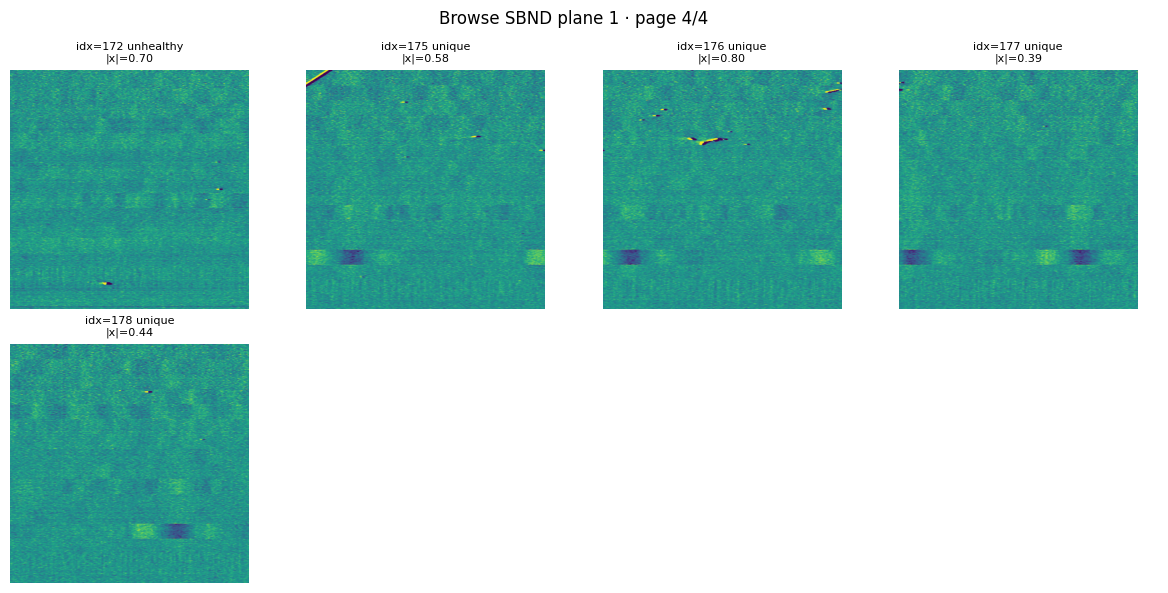

In [93]:
# 2) Browse patches — bump PAGE to scan
PAGE = 4
N_PER_PAGE = 16
NCOLS = 4
CHARGED_ONLY = True

pool = CHARGED if CHARGED_ONLY else np.arange(len(TILES))
if len(pool) == 0:
    raise RuntimeError("No tiles to browse (CHARGED_ONLY emptied the pool?)")

n_pages = max(1, int(np.ceil(len(pool) / N_PER_PAGE)))
PAGE = int(np.clip(PAGE, 0, n_pages - 1))
sl = pool[PAGE * N_PER_PAGE : (PAGE + 1) * N_PER_PAGE]
print(
    f"page {PAGE}/{n_pages - 1}  showing {len(sl)}/{len(pool)} "
    f"({'charged' if CHARGED_ONLY else 'all'})"
)
print("indices:", list(map(int, sl)))

nrows = int(np.ceil(len(sl) / NCOLS))
fig, axes = plt.subplots(nrows, NCOLS, figsize=(3.0 * NCOLS, 3.0 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, idx in zip(axes, sl):
    m = META[int(idx)]
    ax.imshow(np.squeeze(TILES[idx]), vmin=-0.1, vmax=0.1)
    ax.set_title(f"idx={int(idx)} {m['label']}\n|x|={TILE_ABSMAX[idx]:.2f}", fontsize=8)
    ax.axis("off")
for ax in axes[len(sl) :]:
    ax.axis("off")
fig.suptitle(f"Browse SBND plane {PLANE} · page {PAGE}/{n_pages - 1}")
plt.tight_layout()
plt.show()


PATCH_IDX=176  label=unique  plane=1  absmax=0.800
  86414757_75/g4-raw-0_8.h5:9
  86414757_75_g4-raw-0_8.h5_9_p1_y0_x2.npz


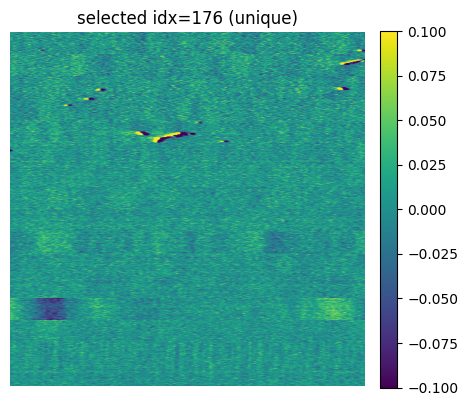

In [94]:
# 3) Choose patch — set PATCH_IDX from the browse grid, then run this cell
PATCH_IDX = int(CHARGED[0]) if len(CHARGED) else 0  # <-- change me after browsing
PATCH_IDX = 176

assert 0 <= PATCH_IDX < len(TILES), (PATCH_IDX, len(TILES))
PATCH = TILES[PATCH_IDX]
M = META[PATCH_IDX]
print(
    f"PATCH_IDX={PATCH_IDX}  label={M['label']}  plane={M['plane']}  "
    f"absmax={TILE_ABSMAX[PATCH_IDX]:.3f}\n  {M['sample_id']}\n  {M['path'].name}"
)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(np.squeeze(PATCH), vmin=-0.1, vmax=0.1)
ax.set_title(f"selected idx={PATCH_IDX} ({M['label']})")
ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()


ddim: ckpt=/exp/sbnd/data/users/gputnam/training-SBND/iterE/results/emabrats2update_0.9999_111000.pt  T=200  device=cuda


vae: mse=0.000470208  ckpt_step=263000
cae: mse=0.000419688  ckpt_step=263000
timestepresp1 
numberinchannels 1
steps 1000 [1000]
predict_xstart False
predict_xprev False
model_mean_type ModelMeanType.EPSILON
num_timesteps 1000
sectioncount [1000]
all steps {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 1

100%|██████████| 200/200 [00:24<00:00,  8.33it/s]


ddim: mse=6.54641e-05  T=200
saved /exp/sbnd/data/users/munjung/anomaly-detection/figures/baselines_sbnd_vae_cae/sbnd_ae_ddim_compare__86414757_75_g4-raw-0_8.h5_9__idx176__T200.pdf
logged /exp/sbnd/data/users/munjung/anomaly-detection/figures/baselines_sbnd_vae_cae/sbnd_ae_ddim_compare.log
SBND same tile · idx=176 (unique) · sample=86414757_75/g4-raw-0_8.h5:9 · plane=1 · file=86414757_75_g4-raw-0_8.h5_9_p1_y0_x2.npz · VAE@263000 CAE@263000 DDIM@emabrats2update_0.9999_111000.pt/T200 · device=cuda · mse_vae=0.000470208 mse_cae=0.000419688 mse_ddim=6.54641e-05


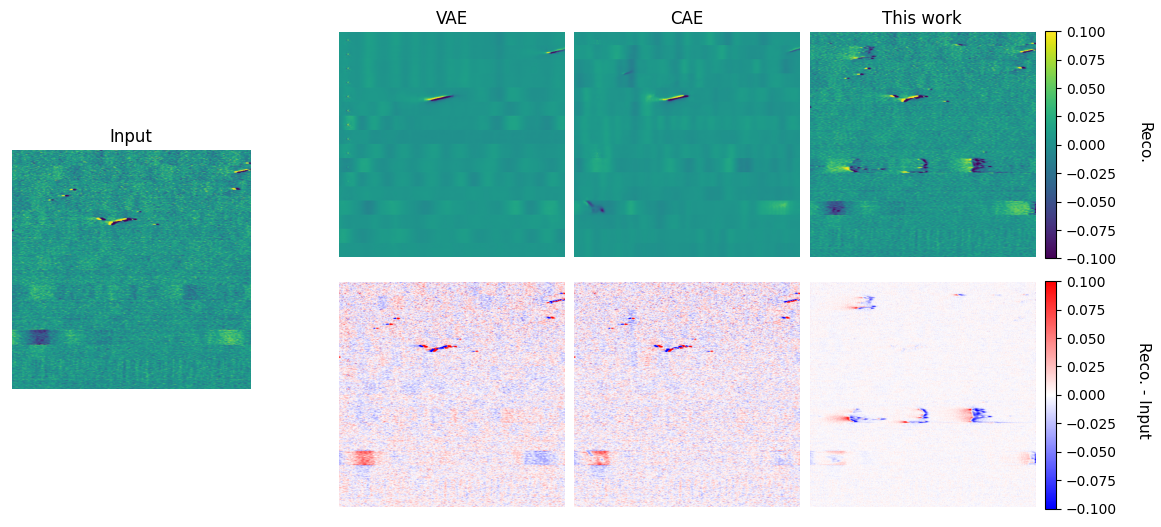

In [95]:
# 4) Run VAE + CAE + DDIM on the chosen patch
assert "PATCH" in dir() and "PATCH_IDX" in dir(), "Run the Choose cell first"
assert DIFF_CKPT.is_file(), DIFF_CKPT
print(f"ddim: ckpt={DIFF_CKPT}  T={DIFF_T}  device={DEVICE}")

x = th.from_numpy(PATCH.astype(np.float32)).unsqueeze(0).to(DEVICE)  # (1,1,H,W)
recos: dict[str, np.ndarray] = {}
mses: dict[str, float] = {}
with th.no_grad():
    for ae in AES:
        model = load_ae(ae, CKPTS[ae])
        reco = model.reconstruct(x).cpu().numpy()[0]
        recos[ae] = reco
        mses[ae] = float(np.mean((reco - PATCH) ** 2))
        del model
        print(f"{ae}: mse={mses[ae]:.6g}  ckpt_step={ema_step(CKPTS[ae])}")

    dmodel, diffusion = load_diffusion(DIFF_CKPT, DIFF_OVERRIDES)
    _, dreco = ddim2ddim_reconstruct(diffusion, dmodel, x, DIFF_T, progress=True)
    recos["ddim"] = dreco.cpu().numpy()[0]
    mses["ddim"] = float(np.mean((recos["ddim"] - PATCH) ** 2))
    print(f"ddim: mse={mses['ddim']:.6g}  T={DIFF_T}")

SHOW_SUPTITLE = False  # metadata goes to the log file by default
M = META[PATCH_IDX]

info = (
    f"SBND same tile · idx={PATCH_IDX} ({M['label']}) · sample={M['sample_id']} · "
    f"plane={M['plane']} · file={M['path'].name} · "
    f"VAE@{ema_step(CKPTS['vae'])} CAE@{ema_step(CKPTS['cae'])} "
    f"DDIM@{DIFF_CKPT.name}/T{DIFF_T} · device={DEVICE} · "
    f"mse_vae={mses['vae']:.6g} mse_cae={mses['cae']:.6g} mse_ddim={mses['ddim']:.6g}"
)

# Layout: Input spans both rows (left); VAE | CAE | This work (reco / reco-input);
# one shared colorbar per row; row labels on the right edge.
COL_LABELS = ("VAE", "CAE", "This work")
COL_KEYS = ("vae", "cae", "ddim")
RECO_CLIM = (-0.1, 0.1)
RES_CLIM = (-0.1, 0.1)

fig = plt.figure(figsize=(13.5, 6.2))
outer = fig.add_gridspec(1, 2, width_ratios=[1.15, 3.4], wspace=0.18)
# Center Input vertically between the two model rows (same panel size, not stretched).
left = outer[0, 0].subgridspec(3, 1, height_ratios=[0.5, 1.0, 0.5], hspace=0.0)
for r in (0, 2):
    ax_pad = fig.add_subplot(left[r, 0])
    ax_pad.axis("off")
ax_in = fig.add_subplot(left[1, 0])
im_in = ax_in.imshow(np.squeeze(PATCH), cmap="viridis", vmin=RECO_CLIM[0], vmax=RECO_CLIM[1])
ax_in.set_title("Input")
ax_in.axis("off")

right = outer[0, 1].subgridspec(
    2, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.06, hspace=0.10
)
ims_reco, ims_res = [], []
for i, (lab, key) in enumerate(zip(COL_LABELS, COL_KEYS)):
    ax_t = fig.add_subplot(right[0, i])
    ax_b = fig.add_subplot(right[1, i])
    im_t = ax_t.imshow(
        np.squeeze(recos[key]), cmap="viridis", vmin=RECO_CLIM[0], vmax=RECO_CLIM[1]
    )
    im_b = ax_b.imshow(
        np.squeeze(recos[key] - PATCH), cmap="bwr", vmin=RES_CLIM[0], vmax=RES_CLIM[1]
    )
    ax_t.set_title(lab)
    ax_t.axis("off")
    ax_b.axis("off")
    ims_reco.append(im_t)
    ims_res.append(im_b)

cax_t = fig.add_subplot(right[0, 3])
cax_b = fig.add_subplot(right[1, 3])
fig.colorbar(ims_reco[0], cax=cax_t)
fig.colorbar(ims_res[0], cax=cax_b)

fig.text(0.965, 0.70, "Reco.", rotation=270, va="center", ha="center", fontsize=11)
fig.text(0.965, 0.30, "Reco. - Input", rotation=270, va="center", ha="center", fontsize=11)

if SHOW_SUPTITLE:
    fig.suptitle(info)
    fig.subplots_adjust(top=0.88)

stem = re.sub(r"[^A-Za-z0-9._-]+", "_", str(M["sample_id"]))
out = FIG_DIR / f"sbnd_ae_ddim_compare__{stem}__idx{PATCH_IDX}__T{DIFF_T}.pdf"
fig.savefig(out, bbox_inches="tight")
log_path = FIG_DIR / "sbnd_ae_ddim_compare.log"
with log_path.open("a") as fh:
    fh.write(f"{out.name}\t{info}\n")
print("saved", out)
print("logged", log_path)
print(info)
plt.show()
